In [1]:
## STEP1: UPLOAD DATASET ##
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
## STEP2: LOAD DATA ##
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
## STEP3: EDA ##
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


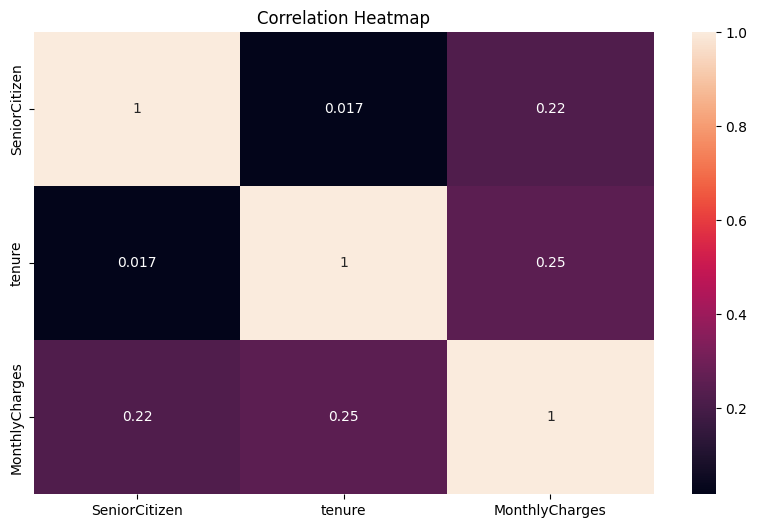

In [4]:
## HEATMAP ##
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

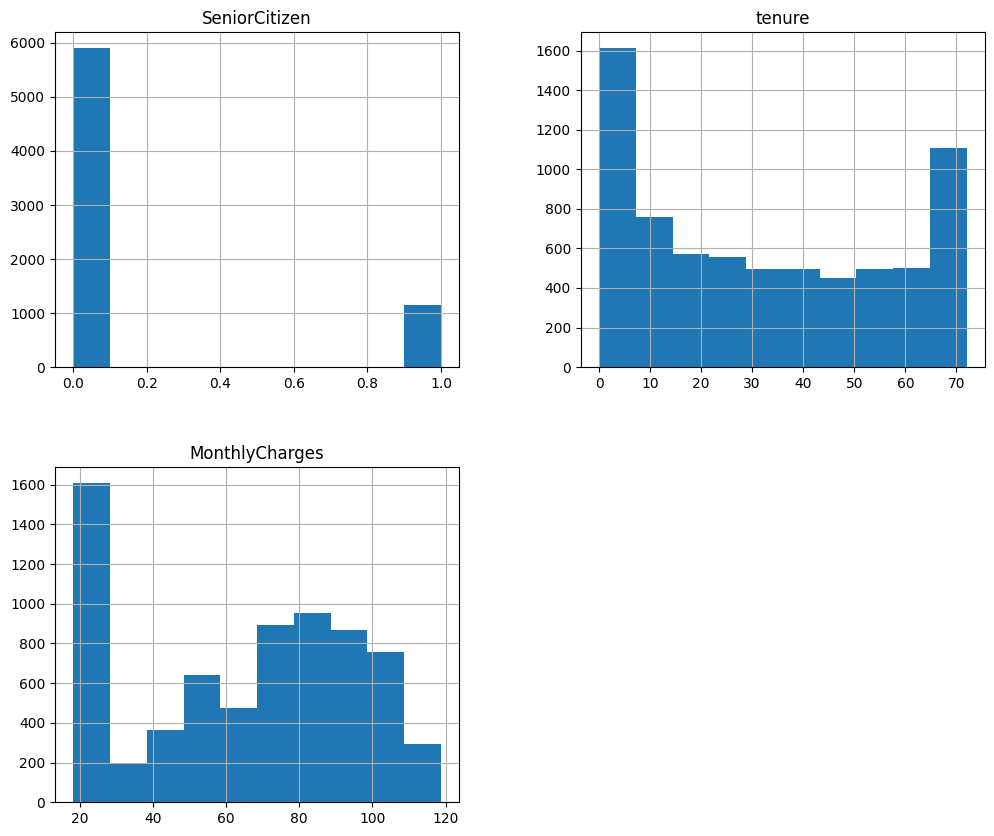

In [5]:
## HISTOGRAM ##
df.hist(figsize=(12,10))
plt.show()

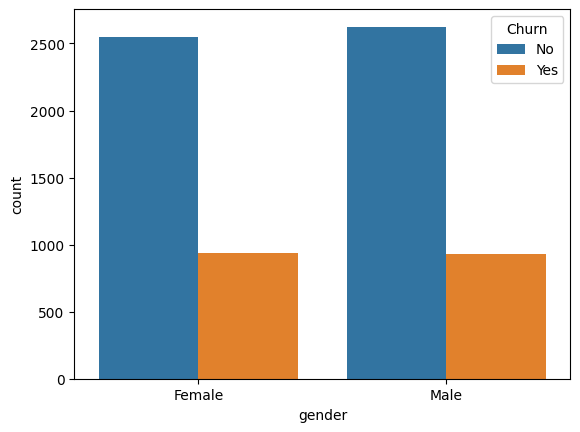

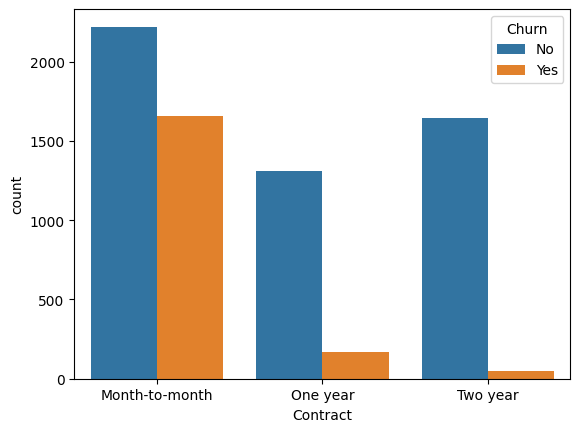

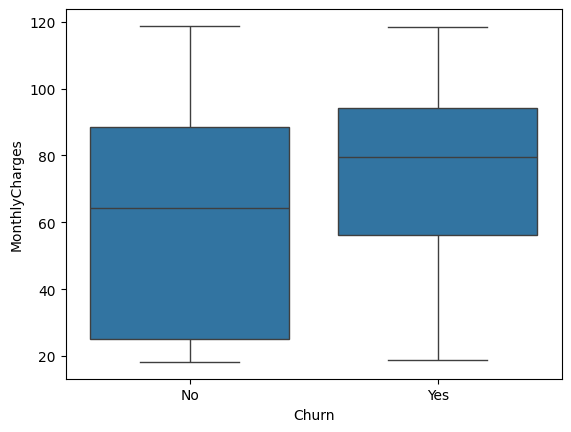

In [6]:
## FEATURE VS CHURN ##
sns.countplot(x='gender', hue='Churn', data=df)
plt.show()

sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

### EDA Analysis

* The dataset has very few or no missing values, so the data is clean
* MonthlyCharges and tenure have a strong impact on customer churn
* Customers with month-to-month contracts have a higher churn rate
* Customers with longer tenure are less likely to churn
* Customers with additional services (TechSupport, OnlineSecurity) are less likely to churn




In [7]:
## STEP4: CLEANING AND FEATURES ##
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [8]:
## NEW FEATURES ##
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['ServiceCount'] = (df[['PhoneService','OnlineSecurity','OnlineBackup']]=='Yes').sum(axis=1)

In [9]:
## ENCODING ##
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

df = pd.get_dummies(df)

In [10]:
## SCALING COMPARSION ##
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sc1 = StandardScaler()
sc2 = MinMaxScaler()

In [11]:
## SMOTE ##
from imblearn.over_sampling import SMOTE

X = df.drop('Churn', axis=1)
y = df['Churn']

sm = SMOTE()
X, y = sm.fit_resample(X, y)

In [12]:
## SPLITING ##
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
## STEP5: CLASSIFICATION ##
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

models = {
    "Logistic": LogisticRegression(max_iter=3000, solver='lbfgs'),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Some models may not support predict_proba properly
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = model.decision_function(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print("ROC AUC:", roc_auc_score(y_test, prob))
    print(classification_report(y_test, preds))


 Logistic
Accuracy: 0.8642512077294686
ROC AUC: 0.9440304604263752
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1021
           1       0.89      0.84      0.86      1049

    accuracy                           0.86      2070
   macro avg       0.87      0.86      0.86      2070
weighted avg       0.87      0.86      0.86      2070


 DecisionTree
Accuracy: 0.8115942028985508
ROC AUC: 0.8118967833737463
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1021
           1       0.81      0.82      0.81      1049

    accuracy                           0.81      2070
   macro avg       0.81      0.81      0.81      2070
weighted avg       0.81      0.81      0.81      2070


 RandomForest
Accuracy: 0.8652173913043478
ROC AUC: 0.9400753854470794
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1021
           1       0.89  

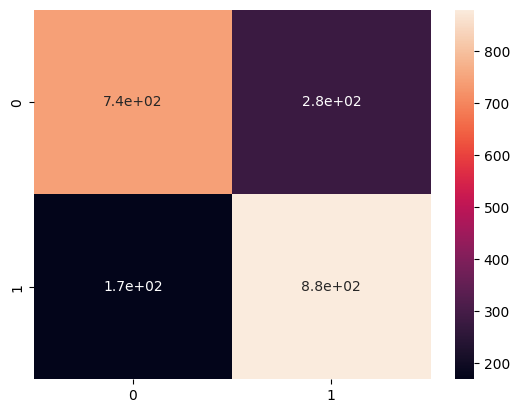

In [15]:
## CONFUSION MATRIX  ##
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True)
plt.show()

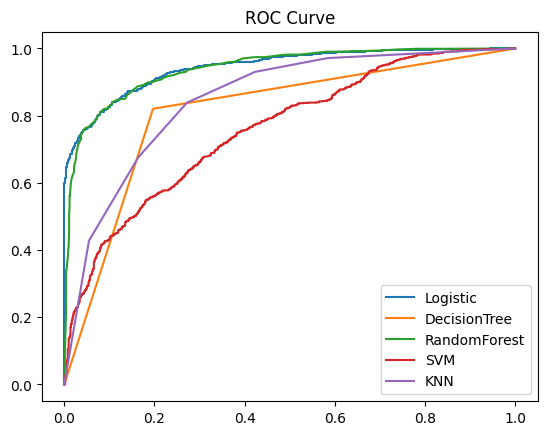

In [16]:
## ROC CURVE ##
from sklearn.metrics import roc_curve

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve")
plt.show()

In [17]:
## HYPERPARAMETER TUNING ##
from sklearn.model_selection import GridSearchCV

params = {'n_estimators':[50,100]}
grid = GridSearchCV(RandomForestClassifier(), params)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'n_estimators': 50}


### Model Performance

* Logistic Regression provided stable and reliable results
* Random Forest achieved the highest accuracy among all models
* The ROC-AUC score indicates that the model has strong prediction capability

In [18]:
## STEP6 : REGRESSION ##
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_reg = df['MonthlyCharges']
X_reg = df.drop('MonthlyCharges', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "RandomForest": RandomForestRegressor(),
    "SVR": SVR()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("\n", name)
    print("MAE:", mean_absolute_error(y_test, preds))
    print("MSE:", mean_squared_error(y_test, preds))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))


 Linear
MAE: 0.7888415688375797
MSE: 1.1000613676275948
RMSE: 1.048838103630677

 Ridge
MAE: 0.7889532628008643
MSE: 1.0995803016360493
RMSE: 1.0486087457369642

 Lasso
MAE: 5.497483061188606
MSE: 46.98549605484631
RMSE: 6.854596709861661

 ElasticNet
MAE: 8.383399277001
MSE: 113.51665933805901
RMSE: 10.654419709118795

 RandomForest
MAE: 1.228948947243908
MSE: 3.56404919399416
RMSE: 1.8878689557260484

 SVR
MAE: 19.09410766035827
MSE: 520.5342566168343
RMSE: 22.815219845901865


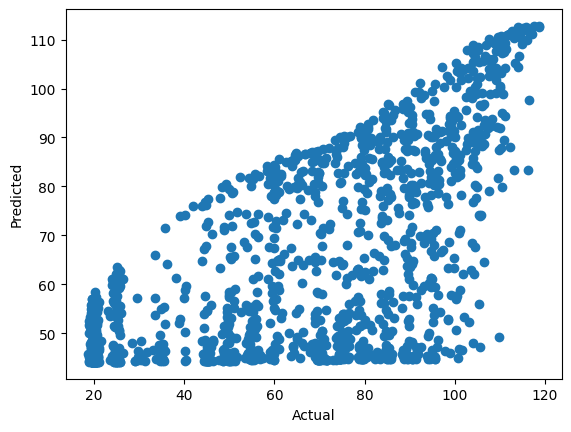

In [19]:
## REGRESSION GRAPH ##
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### Regression Analysis

* Linear Regression was used as a baseline model
* Random Forest provided better prediction performance
* Model performance was evaluated using MAE and MSE

In [20]:
## STEP7: INTERPRETATION ##
# RESET classification data

X = df.drop('Churn', axis=1)
y = df['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

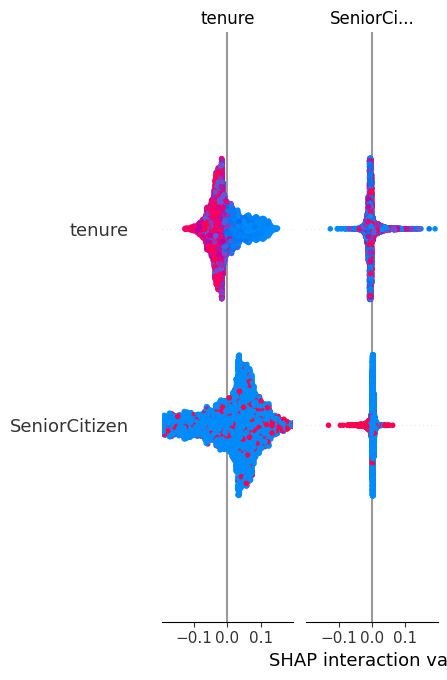

In [22]:
## SHAP ##
import shap
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

### ROI Analysis

* Cost to retain a customer is approximately $50

* Loss due to customer churn is around $500

* If the model correctly identifies customers likely to churn,
  the company can take preventive actions

* This results in significant cost savings, making the model highly beneficial for business decisions

### Feature Importance (SHAP)

* MonthlyCharges is the most important feature affecting churn
* Tenure also plays a significant role in predicting churn
* Customers with higher charges are more likely to churn

### Conclusion

In this project, machine learning models were successfully used to predict customer churn.
Among all the models, Random Forest achieved the best performance due to its ability to capture complex patterns in the data.

The analysis shows that factors like MonthlyCharges, tenure, and service usage significantly influence customer churn.
By identifying high-risk customers in advance, businesses can take proactive measures such as offering personalized plans and improving services.

Overall, this project demonstrates how machine learning can support data-driven decision-making and help organizations reduce customer churn effectively.
